## **Library**

In [309]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score

## **Data Understanding**

In [367]:
df = pd.read_csv(r"C:\Users\Aya_Samy\Documents\Python\sensor-fault-detection.csv")
df.head(10)

,Timestamp,SensorId,Value
0,2017-03-01T23:20:00+03:00,1.0,18.479807
1,2017-03-02T04:00:00+03:00,1.0,19.539112
2,2017-03-23T06:25:00+03:00,1.0,19.250198
3,2017-03-23T19:35:00+03:00,1.0,18.961285
4,2017-04-04T15:10:00+03:00,1.0,25.321623
5,2017-04-04T23:50:00+03:00,1.0,25.418072
6,2017-04-05T04:55:00+03:00,1.0,24.839457
7,2017-04-05T16:25:00+03:00,1.0,24.164511
8,2017-04-07T16:20:00+03:00,1.0,22.718565
9,2017-04-07T23:50:00+03:00,1.0,23.489683


In [311]:
# Number of ows and columns
df.shape

# Column Names
df.columns

Index(['Timestamp', 'SensorId', 'Value'], dtype='str')

In [312]:
# Information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62629 entries, 0 to 62628
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  62629 non-null  str    
 1   SensorId   62624 non-null  float64
 2   Value      62625 non-null  float64
dtypes: float64(2), str(1)
memory usage: 1.4 MB


In [313]:
# Describing the data Statistically
df.describe()

,SensorId,Value
count,62624.0,62625.000000
mean,1.0,24.204039
std,0.0,5.411757
min,1.0,6.886155
25%,1.0,21.369419
50%,1.0,24.550188
75%,1.0,27.443794
max,1.0,149.601822


In [314]:
# Checkng the data types
df.dtypes

Timestamp        str
SensorId     float64
Value        float64
dtype: object

In [315]:
# Coverting Time from string to time format
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df.dtypes

Timestamp    datetime64[us, UTC+03:00]
SensorId                       float64
Value                          float64
dtype: object

In [316]:
# Checking the time range
print(f"Start time: {df['Timestamp'].min()}")
print(f"End time: {df['Timestamp'].max()}")

Start time: 2016-08-01 01:00:00+03:00
End time: 2017-09-01 00:55:00+03:00


## **Data Cleaning**

In [317]:
# Identify how many missing values exist in each column
df.isnull().sum()

Timestamp    0
SensorId     5
Value        4
dtype: int64

In [318]:
# Calculating the missing percentage
missing_percentage = df.isnull().mean() * 100
print(f"Missing Percentage: {missing_percentage}")

Missing Percentage: Timestamp    0.000000
SensorId     0.007984
Value        0.006387
dtype: float64


In [319]:
# Handling the missing values using interpolation in the value
df["Value"] = df["Value"].interpolate()
df["Value"].isnull().sum()

np.int64(0)

In [320]:
# Handling the missing values in the SensorId by dropping them
df = df.dropna(subset=["SensorId"])
df["SensorId"].isnull().sum()

np.int64(0)

In [321]:
# Checking Duplicate rows
df.duplicated().sum()

np.int64(7)

In [322]:
# Removing the duplicated rows
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [323]:
# Sort the Time Series
df.columns
df.dtypes
df = df.sort_values(["Timestamp"])
df = df.reset_index(drop=True)

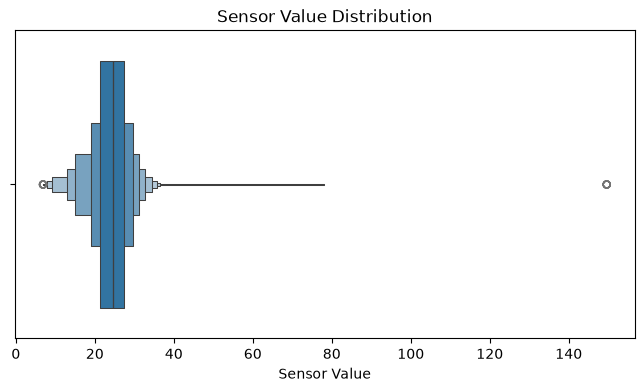

In [324]:
# Detecting the Outliers
# In a sensor fault detection problem, an outlier may represent an actual abnormal sensor behavior.
# Therefore, we will detect and visualize outliers first instead of automatically deleting them.
plt.figure(figsize=(8, 4))
sns.boxenplot(x=df["Value"])
plt.title("Sensor Value Distribution")
plt.xlabel("Sensor Value")
plt.show()

In [325]:
# Detecting Outliers without deleting them
Q1 = df["Value"].quantile(0.25)
Q3 = df["Value"].quantile(0.75)
IQR = Q3 - Q1 # Inter Quartile Range
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df["Value"] < lower_bound) | (df["Value"] > upper_bound)
]
print(f"Number of Outliers: {len(outliers)}")
outlier_percentage = ( len(outliers) / len(df) ) * 100
print(f"Outlier Percentage: {outlier_percentage}")

Number of Outliers: 1791
Outlier Percentage: 2.8602456201989876


## **Exploratory Data Analsis (EDA)**

In [326]:
# Checking how many sensors or only one sensor
df["SensorId"].unique()
df["SensorId"].value_counts()

SensorId
1.0    62617
Name: count, dtype: int64

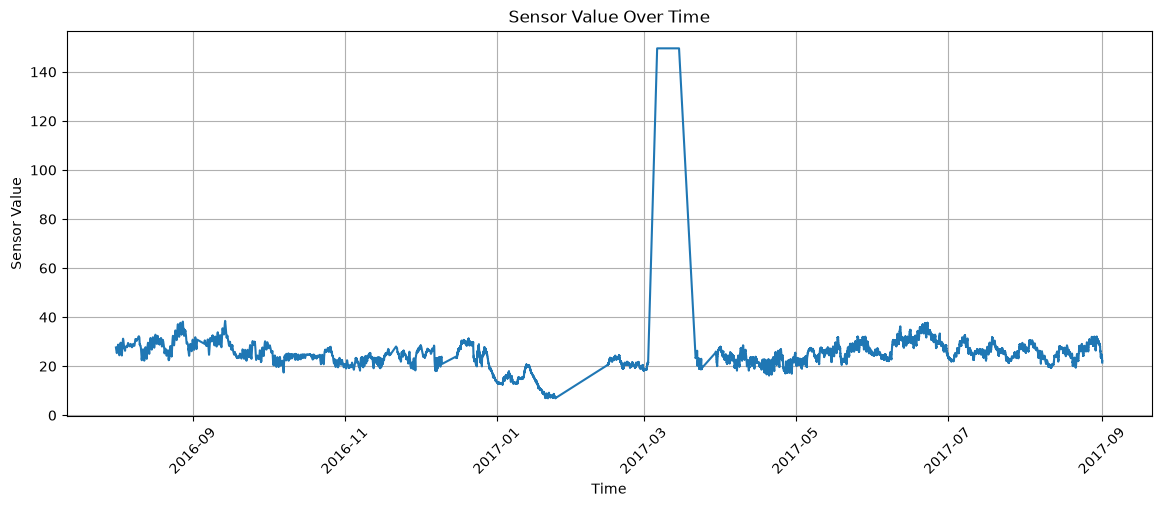

In [327]:
# Plotting the only one sensor values over time
plt.figure(figsize=(14, 5))
plt.plot(df["Timestamp"], df["Value"])
plt.title("Sensor Value Over Time")
plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.xticks(rotation=45)
plt.grid()
plt.show()


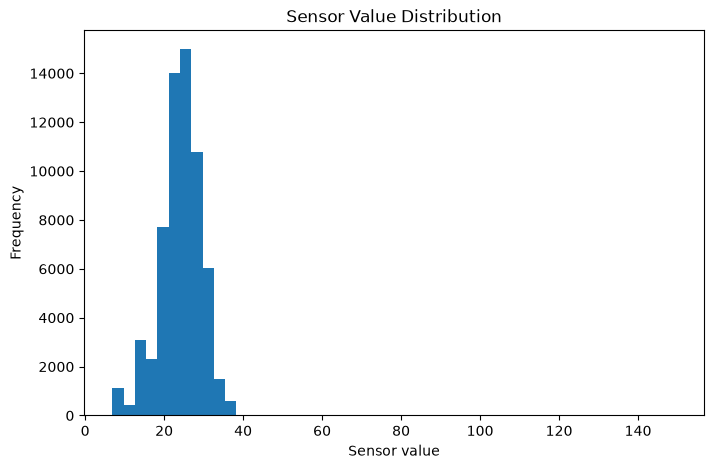

In [328]:
# Distribution of sensor values in a histogram
plt.figure(figsize=(8, 5))
plt.hist(df["Value"], bins=50)
plt.xlabel("Sensor value")
plt.ylabel("Frequency")
plt.title("Sensor Value Distribution")
plt.show()

## **Feature Engineering**

In [329]:
# Calculate the time difference between consecutive measurements
df["Timestamp"].is_monotonic_increasing
df["Time_Diff"] = (
    df["Timestamp"].diff().dt.total_seconds()
)
df["Time_Diff"].value_counts().head(10)

# Arranging the Time_Diff in acsending order
df["Time_Diff"].value_counts().sort_index().head(10)

Time_Diff
300.0     59478
600.0        29
900.0        68
1200.0       11
1500.0        4
1800.0        3
2100.0        3
2700.0        1
3600.0     2935
3900.0       21
Name: count, dtype: int64

In [330]:
# Displaing the large gaps
df[df["Time_Diff"] > 3600][["Timestamp", "Value", "Time_Diff"]].head()

large_gaps = df[df["Time_Diff"] > 3600]
print(f"Number of Gaps > 1 hour: {len(large_gaps)}")
print(f"Percentage of Gaps > 1 hour: {len(large_gaps)/len(df) * 100}")

Number of Gaps > 1 hour: 84
Percentage of Gaps > 1 hour: 0.13414887330916522


In [331]:
# It is a small percentage of large gaps so it won't be excloded
# The dataset predominantly contains 5-minute intervals.
# but the sampling interval is irregular and varies across the time series.
# Rolling mean
df["Rolling_Mean"] = ( df["Value"].rolling(window=10).mean() )

# Rolling Standard Deviation
df["Rolling_Std"] = ( df["Value"].rolling(window=10).std() )

# Deviation from Rolling Mean
df["Deviation_From_Mean"] = ( df["Value"] - df["Rolling_Mean"] )

print(f"Deviation From Mean: {df['Deviation_From_Mean']}")

# Checking Missing Values Again
df.isnull().sum()


Deviation From Mean: 0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
62612   -0.183098
62613   -0.317981
62614   -0.346899
62615   -0.202349
62616   -0.250539
Name: Deviation_From_Mean, Length: 62617, dtype: float64


Timestamp              0
SensorId               0
Value                  0
Time_Diff              1
Rolling_Mean           9
Rolling_Std            9
Deviation_From_Mean    9
dtype: int64

In [332]:
# Dropping the NULL Values
print(f"Shape before dropping NaN: {df.shape}")
df = df.dropna().reset_index(drop=True)
print(f"Shape after dropping NaN: {df.shape}")
df.isnull().sum()

Shape before dropping NaN: (62617, 7)
Shape after dropping NaN: (62608, 7)


Timestamp              0
SensorId               0
Value                  0
Time_Diff              0
Rolling_Mean           0
Rolling_Std            0
Deviation_From_Mean    0
dtype: int64

In [333]:
# Difference between consecutive sensor values
df["value_diff"] = df["Value"].diff()

# Rate of change
df["Rate_Of_Change"] = df["value_diff"] / df["Time_Diff"]


print(df[["Timestamp", "Value", "value_diff", "Rate_Of_Change"]].head())

                  Timestamp      Value  value_diff  Rate_Of_Change
0 2016-08-01 13:00:00+03:00  26.382582         NaN             NaN
1 2016-08-01 14:00:00+03:00  26.671986    0.289404        0.000080
2 2016-08-01 15:00:00+03:00  27.057861    0.385876        0.000107
3 2016-08-01 16:00:00+03:00  27.250818    0.192957        0.000054
4 2016-08-01 17:00:00+03:00  27.540283    0.289465        0.000080


In [334]:
# Inspect the highest sensor values to identify possible abnormal behavior
top_values = df.nlargest(
    20,
    "Value"
)[
    [
        "Timestamp",
        "Value",
        "value_diff",
        "Time_Diff",
        "Rate_Of_Change"
    ]
]

print(top_values)

                      Timestamp       Value  value_diff  Time_Diff  \
17799 2017-03-06 07:50:00+03:00  149.601822  128.136051   313200.0   
17800 2017-03-06 19:10:00+03:00  149.601822    0.000000    40800.0   
17801 2017-03-07 13:00:00+03:00  149.601822    0.000000    64200.0   
17802 2017-03-08 03:10:00+03:00  149.601822    0.000000    51000.0   
17803 2017-03-12 03:00:00+03:00  149.601822    0.000000   345000.0   
17804 2017-03-14 03:50:00+03:00  149.601822    0.000000   175800.0   
17805 2017-03-14 04:00:00+03:00  149.601822    0.000000      600.0   
17806 2017-03-15 02:45:00+03:00  149.601822    0.000000    81900.0   
951   2016-09-13 21:00:00+03:00   38.474796    0.388882     3600.0   
952   2016-09-13 22:00:00+03:00   38.377571   -0.097225     3600.0   
629   2016-08-27 22:00:00+03:00   38.183121    0.097206     3600.0   
627   2016-08-27 20:00:00+03:00   38.085915    0.097225     3600.0   
628   2016-08-27 21:00:00+03:00   38.085915    0.000000     3600.0   
950   2016-09-13 20:

In [335]:
# Locate the observation with the maximum sensor value
max_index = df["Value"].idxmax()

print(
    df.loc[
        max_index - 10:max_index + 10,
        [
            "Timestamp",
            "Value",
            "value_diff",
            "Time_Diff",
            "Rate_Of_Change"
        ]
    ]
)

                      Timestamp       Value  value_diff  Time_Diff  \
17789 2017-03-02 16:05:00+03:00   21.465771   -0.096371      300.0   
17790 2017-03-02 16:10:00+03:00   21.369419   -0.096352      300.0   
17791 2017-03-02 16:15:00+03:00   21.465771    0.096352      300.0   
17792 2017-03-02 16:20:00+03:00   21.369419   -0.096352      300.0   
17793 2017-03-02 16:25:00+03:00   21.369419    0.000000      300.0   
17794 2017-03-02 16:30:00+03:00   21.273069   -0.096350      300.0   
17795 2017-03-02 16:35:00+03:00   21.369419    0.096350      300.0   
17796 2017-03-02 16:40:00+03:00   21.465771    0.096352      300.0   
17797 2017-03-02 16:45:00+03:00   21.658491    0.192720      300.0   
17798 2017-03-02 16:50:00+03:00   21.465771   -0.192720      300.0   
17799 2017-03-06 07:50:00+03:00  149.601822  128.136051   313200.0   
17800 2017-03-06 19:10:00+03:00  149.601822    0.000000    40800.0   
17801 2017-03-07 13:00:00+03:00  149.601822    0.000000    64200.0   
17802 2017-03-08 03:

In [336]:
# Group consecutive observations with the same sensor value
df["same_value_group"] = (
    df["Value"] != df["Value"].shift()
).cumsum()

# Summarize the duration and size of each constant-value group
value_groups = (
    df.groupby("same_value_group")
      .agg(
          Value=("Value", "first"),
          Count=("Value", "size"),
          Start=("Timestamp", "first"),
          End=("Timestamp", "last")
      )
)

# Calculate how long each constant-value group lasted
value_groups["Duration_hours"] = (
    value_groups["End"] - value_groups["Start"]
).dt.total_seconds() / 3600

# Display the longest constant-value periods
long_constant = value_groups.sort_values(
    "Duration_hours",
    ascending=False
)

print(
    long_constant.head(20)[
        ["Value", "Count", "Start", "End", "Duration_hours"]
    ]
)

                       Value  Count                     Start  \
same_value_group                                                
9400              149.601822      8 2017-03-06 07:50:00+03:00   
9230               18.864992      7 2017-03-01 01:15:00+03:00   
1535               24.839457     12 2016-10-16 19:00:00+03:00   
1515               23.875282      3 2016-10-15 04:00:00+03:00   
5127               13.005086     77 2017-01-01 22:50:00+03:00   
28233              27.057861     59 2017-08-15 04:00:00+03:00   
24341              30.339306      2 2017-07-08 15:10:00+03:00   
23719              22.525805     52 2017-07-02 17:25:00+03:00   
2479               26.479050      5 2016-12-04 14:00:00+03:00   
968                23.875282      5 2016-09-19 02:00:00+03:00   
1090               28.987822      5 2016-09-25 02:00:00+03:00   
28235              27.057861     49 2017-08-15 09:00:00+03:00   
28247              27.636770     45 2017-08-15 16:15:00+03:00   
27910              20.695

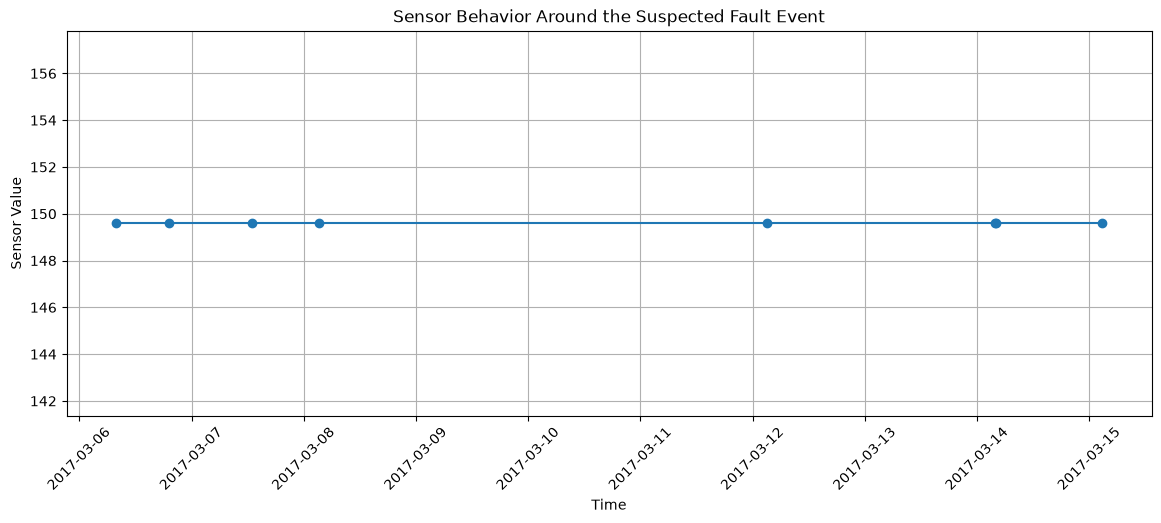

In [337]:
# Define the time window around the suspected abnormal event
fault_start = pd.Timestamp("2017-03-06 00:00:00", tz="Africa/Cairo")
fault_end = pd.Timestamp("2017-03-16 00:00:00", tz="Africa/Cairo")

fault_window = df[
    (df["Timestamp"] >= fault_start) &
    (df["Timestamp"] <= fault_end)
]

plt.figure(figsize=(14, 5))

plt.plot(
    fault_window["Timestamp"],
    fault_window["Value"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.title("Sensor Behavior Around the Suspected Fault Event")

plt.grid()
plt.xticks(rotation=45)

plt.show()


In [338]:
# Display observations corresponding to the suspected abnormal value
print(
    fault_window[
        fault_window["Value"] == 149.6018219
    ][
        ["Timestamp", "Value"]
    ].to_string(index=False)
)

                Timestamp      Value
2017-03-06 07:50:00+03:00 149.601822
2017-03-06 19:10:00+03:00 149.601822
2017-03-07 13:00:00+03:00 149.601822
2017-03-08 03:10:00+03:00 149.601822
2017-03-12 03:00:00+03:00 149.601822
2017-03-14 03:50:00+03:00 149.601822
2017-03-14 04:00:00+03:00 149.601822
2017-03-15 02:45:00+03:00 149.601822


In [339]:
normal_values = df.loc[
    df["Value"] != 149.6018219,
    "Value"
]
print(
    normal_values.quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)
print(normal_values.describe())
print(
    (df["Time_Diff"] == 300).sum()
)
print(
    df["Time_Diff"].value_counts().head(10)
)

0.01     8.223940
0.05    13.866229
0.25    21.369419
0.50    24.550188
0.75    27.443794
0.95    31.691204
0.99    35.267426
Name: Value, dtype: float64
count    62600.000000
mean        24.187222
std          5.223465
min          6.886155
25%         21.369419
50%         24.550188
75%         27.443794
max         38.474796
Name: Value, dtype: float64
59478
Time_Diff
300.0      59478
3600.0      2928
900.0         68
600.0         29
3900.0        21
7500.0        11
1200.0        11
7200.0        10
1500.0         4
10800.0        3
Name: count, dtype: int64


In [340]:
# Create a separate copy for synthetic fault injection
# The original cleaned dataset remains unchanged
synthetic_df = df.copy()
print("Original shape:", df.shape)
print("Synthetic shape:", synthetic_df.shape)


Original shape: (62608, 10)
Synthetic shape: (62608, 10)


In [341]:
# Identify continuous 5-minute sampling segments
continuous = df["Time_Diff"] == 300

segment_id = continuous.ne(continuous.shift()).cumsum()

segments = (
    df[continuous]
    .assign(segment_id=segment_id[continuous])
    .groupby("segment_id")
    .agg(
        Start_Index=("Value", lambda x: x.index.min()),
        End_Index=("Value", lambda x: x.index.max()),
        Length=("Value", "size"),
        Start_Time=("Timestamp", "first"),
        End_Time=("Timestamp", "last")
    )
    .sort_values("Length", ascending=False)
)
# Display the longest continuous segments
print(segments.head(10))

segment_start = 19878
segment_end = 22064

normal_segment = df.loc[
    segment_start:segment_end
].copy()

print(normal_segment[[
    "Timestamp",
    "Value"
]].head(20))
print(normal_segment["Value"].describe())

            Start_Index  End_Index  Length                Start_Time  \
segment_id                                                             
176               19878      22064    2187 2017-04-03 11:50:00+03:00   
262               44010      46094    2085 2017-06-27 08:00:00+03:00   
290               52381      54381    2001 2017-07-27 08:10:00+03:00   
226               32510      34479    1970 2017-05-17 23:00:00+03:00   
190               23845      25750    1906 2017-04-17 14:10:00+03:00   
296               55052      56837    1786 2017-08-05 15:05:00+03:00   
302               58704      60455    1752 2017-08-18 07:45:00+03:00   
156               15687      17269    1583 2017-02-22 15:10:00+03:00   
204               29682      31103    1422 2017-05-08 00:10:00+03:00   
284               50792      52205    1414 2017-07-21 13:20:00+03:00   

                            End_Time  
segment_id                            
176        2017-04-11 02:00:00+03:00  
262        2017-07

In [342]:
# Inject a short-duration step/bias fault
step_start = 20500
step_end = 20504

print(
    synthetic_df.loc[
        step_start:step_end,
        ["Timestamp", "Value"]
    ]
)

# Add a +20 sensor bias during the selected interval
synthetic_df.loc[
    step_start:step_end,
    "Value"
] += 20

                      Timestamp      Value
20500 2017-04-05 15:40:00+03:00  24.068102
20501 2017-04-05 15:45:00+03:00  24.068102
20502 2017-04-05 15:50:00+03:00  24.164511
20503 2017-04-05 15:55:00+03:00  24.164511
20504 2017-04-05 16:00:00+03:00  24.164511


In [343]:
# Initialize all observations as normal
synthetic_df["Fault"] = 0

# Label the injected step/bias event as a fault
synthetic_df.loc[
    step_start:step_end,
    "Fault"
] = 1

In [344]:
# Removing NULL
synthetic_model_df = synthetic_df.dropna().reset_index(drop=True)
print("Before dropna:", synthetic_df.shape)
print("After dropna:", synthetic_model_df.shape)
print(
    synthetic_model_df["Fault"].value_counts()
)


Before dropna: (62608, 11)
After dropna: (62607, 11)
Fault
0    62602
1        5
Name: count, dtype: int64


In [345]:
# Check the final class distribution
class_counts = synthetic_model_df["Fault"].value_counts()

class_percentages = (
    synthetic_model_df["Fault"]
    .value_counts(normalize=True)
    * 100
)

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)

# Calculate the imbalance ratio between normal and fault observations
imbalance_ratio = (
    class_counts[0] /
    class_counts[1]
)

print("\nImbalance Ratio (Normal : Fault):")
print(imbalance_ratio)

Class Counts:
Fault
0    62602
1        5
Name: count, dtype: int64

Class Percentages:
Fault
0    99.992014
1     0.007986
Name: proportion, dtype: float64

Imbalance Ratio (Normal : Fault):
12520.4


In [346]:
# Inject a single-point spike fault
spike_index = 45000

print(
    synthetic_df.loc[
        spike_index - 3 : spike_index + 3,
        ["Timestamp", "Value", "Fault"]
    ]
)
spike_index = 45000

synthetic_df.loc[
    spike_index,
    "Value"
] = (
    synthetic_df.loc[
        spike_index,
        "Value"
    ] + 10
)
synthetic_df.loc[
    spike_index,
    "Fault"
] = 1
print(
    synthetic_df.loc[
        44997:45003,
        ["Timestamp", "Value", "Fault"]
    ]
)

                      Timestamp      Value  Fault
44997 2017-06-30 18:15:00+03:00  25.418072      0
44998 2017-06-30 18:20:00+03:00  25.610950      0
44999 2017-06-30 18:25:00+03:00  25.514521      0
45000 2017-06-30 18:30:00+03:00  25.321623      0
45001 2017-06-30 18:35:00+03:00  25.225193      0
45002 2017-06-30 18:40:00+03:00  24.935886      0
45003 2017-06-30 18:45:00+03:00  24.935886      0
                      Timestamp      Value  Fault
44997 2017-06-30 18:15:00+03:00  25.418072      0
44998 2017-06-30 18:20:00+03:00  25.610950      0
44999 2017-06-30 18:25:00+03:00  25.514521      0
45000 2017-06-30 18:30:00+03:00  35.321623      1
45001 2017-06-30 18:35:00+03:00  25.225193      0
45002 2017-06-30 18:40:00+03:00  24.935886      0
45003 2017-06-30 18:45:00+03:00  24.935886      0


In [347]:
# Inject a gradual drift fault
drift_start = 53000
drift_end = 53019
drift_values = synthetic_df.loc[
    drift_start:drift_end, "Value"
].copy()

drift = np.linspace(0, 8, len(drift_values))

synthetic_df.loc[
    drift_start:drift_end, "Value"
] = drift_values + drift

synthetic_df.loc[
    drift_start:drift_end, "Fault"
] = 1
print(
    synthetic_df.loc[
        drift_start - 2 : drift_end + 2,
        ["Timestamp", "Value", "Fault"]
    ]
)
print("Original first value:", drift_values.iloc[0])
print("Original last value:", drift_values.iloc[-1])

print("Injected drift:", drift[0], "to", drift[-1])

                      Timestamp      Value  Fault
52998 2017-07-29 11:35:00+03:00  24.743029      0
52999 2017-07-29 11:40:00+03:00  24.743029      0
53000 2017-07-29 11:45:00+03:00  24.935886      1
53001 2017-07-29 11:50:00+03:00  25.356939      1
53002 2017-07-29 11:55:00+03:00  25.874421      1
53003 2017-07-29 12:00:00+03:00  26.391923      1
53004 2017-07-29 12:05:00+03:00  26.812976      1
53005 2017-07-29 12:10:00+03:00  27.426886      1
53006 2017-07-29 12:15:00+03:00  27.847939      1
53007 2017-07-29 12:20:00+03:00  28.268991      1
53008 2017-07-29 12:25:00+03:00  28.786493      1
53009 2017-07-29 12:30:00+03:00  29.303994      1
53010 2017-07-29 12:35:00+03:00  29.725047      1
53011 2017-07-29 12:40:00+03:00  30.242529      1
53012 2017-07-29 12:45:00+03:00  30.663582      1
53013 2017-07-29 12:50:00+03:00  31.084635      1
53014 2017-07-29 12:55:00+03:00  31.602136      1
53015 2017-07-29 13:00:00+03:00  32.023189      1
53016 2017-07-29 13:05:00+03:00  32.540690      1


In [348]:
# Inject a stuck-at fault by keeping the sensor value constant
stuck_start = 57000
stuck_end = 57019

stuck_value = synthetic_df.loc[stuck_start, "Value"]

synthetic_df.loc[
    stuck_start:stuck_end, "Value"
] = stuck_value

synthetic_df.loc[
    stuck_start:stuck_end, "Fault"
] = 1
print(
    synthetic_df.loc[
        stuck_start - 2 : stuck_end + 2,
        ["Timestamp", "Value", "Fault"]
    ]
)

                      Timestamp      Value  Fault
56998 2017-08-12 09:20:00+03:00  20.502342      0
56999 2017-08-12 09:25:00+03:00  20.502342      0
57000 2017-08-12 09:30:00+03:00  20.502342      1
57001 2017-08-12 09:35:00+03:00  20.502342      1
57002 2017-08-12 09:40:00+03:00  20.502342      1
57003 2017-08-12 09:45:00+03:00  20.502342      1
57004 2017-08-12 09:50:00+03:00  20.502342      1
57005 2017-08-12 09:55:00+03:00  20.502342      1
57006 2017-08-12 10:00:00+03:00  20.502342      1
57007 2017-08-12 10:05:00+03:00  20.502342      1
57008 2017-08-12 10:10:00+03:00  20.502342      1
57009 2017-08-12 10:15:00+03:00  20.502342      1
57010 2017-08-12 10:20:00+03:00  20.502342      1
57011 2017-08-12 10:25:00+03:00  20.502342      1
57012 2017-08-12 10:30:00+03:00  20.502342      1
57013 2017-08-12 10:35:00+03:00  20.502342      1
57014 2017-08-12 10:40:00+03:00  20.502342      1
57015 2017-08-12 10:45:00+03:00  20.502342      1
57016 2017-08-12 10:50:00+03:00  20.502342      1


In [349]:
# Calculate the difference between consecutive sensor readings
synthetic_df["value_diff"] = (
    synthetic_df["Value"].diff()
)

# Calculate the time difference between consecutive observations
synthetic_df["Time_Diff"] = (
    synthetic_df["Timestamp"]
    .diff()
    .dt.total_seconds()
)

# Calculate the rate of sensor-value change over time
synthetic_df["Rate_Of_Change"] = (
    synthetic_df["value_diff"] /
    synthetic_df["Time_Diff"]
)

# Calculate the rolling mean over the previous 10 observations
synthetic_df["Rolling_Mean"] = (
    synthetic_df["Value"]
    .rolling(window=10)
    .mean()
)

# Calculate local variability using rolling standard deviation
synthetic_df["Rolling_Std"] = (
    synthetic_df["Value"]
    .rolling(window=10)
    .std()
)

# Measure the deviation from the local rolling mean
synthetic_df["Deviation_From_Mean"] = (
    synthetic_df["Value"] -
    synthetic_df["Rolling_Mean"]
)

In [350]:
# Check missing values created by feature engineering
print(
    synthetic_df[
        [
            "value_diff",
            "Time_Diff",
            "Rate_Of_Change",
            "Rolling_Mean",
            "Rolling_Std",
            "Deviation_From_Mean"
        ]
    ].isnull().sum()
)

value_diff             1
Time_Diff              1
Rate_Of_Change         1
Rolling_Mean           9
Rolling_Std            9
Deviation_From_Mean    9
dtype: int64


In [351]:
# Assign a descriptive fault type to each injected event
synthetic_df["Fault_Type"] = "Normal"

synthetic_df.loc[
    20500:20504,
    "Fault_Type"
] = "Step_Bias"

synthetic_df.loc[
    45000,
    "Fault_Type"
] = "Spike"

synthetic_df.loc[
    53000:53019,
    "Fault_Type"
] = "Drift"

synthetic_df.loc[
    57000:57019,
    "Fault_Type"
] = "Stuck_At"

# Remove rows containing NaN values created by differencing and rolling features
synthetic_model_df = (
    synthetic_df
    .dropna()
    .reset_index(drop=True)
)

print("Shape:", synthetic_model_df.shape)


Shape: (62599, 12)


In [352]:
# Assign a unique ID to each fault event
# 0 represents normal observations
synthetic_model_df["Fault_Event_ID"] = 0

synthetic_model_df.loc[
    synthetic_model_df["Fault_Type"] == "Step_Bias",
    "Fault_Event_ID"
] = 1

synthetic_model_df.loc[
    synthetic_model_df["Fault_Type"] == "Spike",
    "Fault_Event_ID"
] = 2

synthetic_model_df.loc[
    synthetic_model_df["Fault_Type"] == "Drift",
    "Fault_Event_ID"
] = 3

synthetic_model_df.loc[
    synthetic_model_df["Fault_Type"] == "Stuck_At",
    "Fault_Event_ID"
] = 4

In [353]:
# Define the input features used by the classifier
feature_columns = [
    "value_diff",
    "Time_Diff",
    "Rate_Of_Change",
    "Rolling_Mean",
    "Rolling_Std",
    "Deviation_From_Mean"
]
# Create the feature matrix
X = synthetic_model_df[feature_columns]

# Create the binary target variable
Y = synthetic_model_df["Fault"]

print(f"X Shape: {X.shape}")
print(f"Y Shape: {Y.shape}")
print(f"Class Distribution: {Y.value_counts()}")
print(f"Missing Values: {X.isnull().sum()}")



X Shape: (62599, 6)
Y Shape: (62599,)
Class Distribution: Fault
0    62553
1       46
Name: count, dtype: int64
Missing Values: value_diff             0
Time_Diff              0
Rate_Of_Change         0
Rolling_Mean           0
Rolling_Std            0
Deviation_From_Mean    0
dtype: int64


In [354]:
# Split the time-series data chronologically
# to avoid using future observations for training
n = len(synthetic_model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = synthetic_model_df.iloc[:train_end].copy()
val_df = synthetic_model_df.iloc[train_end:val_end].copy()
test_df = synthetic_model_df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Train Faults:")
print(train_df["Fault"].value_counts())

print("\nValidation Faults:")
print(val_df["Fault"].value_counts())

print("\nTest Faults:")
print(test_df["Fault"].value_counts())

Train: (43819, 13)
Validation: (9390, 13)
Test: (9390, 13)
Train Faults:
Fault
0    43814
1        5
Name: count, dtype: int64

Validation Faults:
Fault
0    9369
1      21
Name: count, dtype: int64

Test Faults:
Fault
0    9370
1      20
Name: count, dtype: int64


In [355]:
# Create feature and target subsets for each data split
X_train = train_df[feature_columns]
Y_train = train_df["Fault"]

X_val = val_df[feature_columns]
Y_val = val_df["Fault"]

X_test = test_df[feature_columns]
Y_test = test_df["Fault"]

print(f"Training set: {Y_train.value_counts()}")
print(f"Testing set: {Y_test.value_counts()}")
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Training set: Fault
0    43814
1        5
Name: count, dtype: int64
Testing set: Fault
0    9370
1      20
Name: count, dtype: int64
Train Shape: (43819, 6)
Test Shape: (9390, 6)


## **Feature Scaling**

In [356]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (43819, 6)
X_val_scaled shape: (9390, 6)
X_test_scaled shape: (9390, 6)


## **Classification**

In [357]:
# Logistic regression
model = LogisticRegression(class_weight="balanced", 
                           random_state=42,
                           max_iter=1000)

model.fit(X_train_scaled, Y_train)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

## **Validation**

In [358]:
# Prediction on the test set
Y_val_pred = model.predict(X_val_scaled)

Y_val_prob = model.predict_proba(X_val_scaled)[:, 1]

print("Validation predictions:")
print(Y_val_pred[:30])

print("\nValidation probabilities:")
print(Y_val_prob[:10])

Validation predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Validation probabilities:
[0.00096418 0.00082829 0.00103055 0.00111074 0.00076051 0.00119354
 0.00088258 0.00082686 0.00089827 0.00090478]


In [359]:
# Confusion matrix
cm = confusion_matrix(Y_val, Y_val_pred)

print(f"Validation Confusion Matrix: {cm}")

Validation Confusion Matrix: [[9369    0]
 [  20    1]]


In [360]:
#Classification report
print(classification_report(
    Y_val,
    Y_val_pred,
    target_names=["Normal", "Fault"],
    zero_division=0
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9369
       Fault       1.00      0.05      0.09        21

    accuracy                           1.00      9390
   macro avg       1.00      0.52      0.54      9390
weighted avg       1.00      1.00      1.00      9390



In [361]:
# Average precision score
ap = average_precision_score(Y_val, Y_val_prob)

print("Validation Average Precision:", ap)

Validation Average Precision: 0.8550512900903924


## **Testing**

In [362]:
# tesing set
Y_test_pred = model.predict(X_test_scaled)

Y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Test predictions:")
print(Y_test_pred[:30])

print("\nTest probabilities:")
print(Y_test_prob[:10])

Test predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Test probabilities:
[0.0005384  0.00054179 0.00054474 0.00054723 0.00054912 0.00047825
 0.00052053 0.00052485 0.00052863 0.00053196]


In [363]:
# Confussion matrix on the test set
cm_test = confusion_matrix(Y_test, Y_test_pred)

print("Test Confusion Matrix:")
print(cm_test)


Test Confusion Matrix:
[[9370    0]
 [  20    0]]


In [364]:
# Classification report on the test set
print(classification_report(
    Y_test,
    Y_test_pred,
    target_names=["Normal", "Fault"],
    zero_division=0
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9370
       Fault       0.00      0.00      0.00        20

    accuracy                           1.00      9390
   macro avg       0.50      0.50      0.50      9390
weighted avg       1.00      1.00      1.00      9390



In [365]:
# Average precision score on the test set
ap_test = average_precision_score(Y_test, Y_test_prob)

print("Test Average Precision:", ap_test)

Test Average Precision: 0.0017077452901476055


## **Error Analysis**

In [366]:
# Error Analysis
test_results = test_df[
    test_df["Fault"] == 1
][
    feature_columns + ["Value", "Fault_Type"]
].copy()

test_results["Predicted_Fault"] = Y_test_pred[
    test_df["Fault"].values == 1
]

test_results["Fault_Probability"] = Y_test_prob[
    test_df["Fault"].values == 1
]

print(test_results)

       value_diff  Time_Diff  Rate_Of_Change  Rolling_Mean  Rolling_Std  \
56991         0.0      300.0             0.0     20.454177     0.050771   
56992         0.0      300.0             0.0     20.463810     0.049745   
56993         0.0      300.0             0.0     20.463810     0.049745   
56994         0.0      300.0             0.0     20.473443     0.046532   
56995         0.0      300.0             0.0     20.483076     0.040617   
56996         0.0      300.0             0.0     20.492709     0.030462   
56997         0.0      300.0             0.0     20.502342     0.000001   
56998         0.0      300.0             0.0     20.502342     0.000001   
56999         0.0      300.0             0.0     20.502342     0.000001   
57000         0.0      300.0             0.0     20.502342     0.000001   
57001         0.0      300.0             0.0     20.502342     0.000001   
57002         0.0      300.0             0.0     20.502342     0.000001   
57003         0.0      30